# CHURN DATA ANALYSIS

### DATA IMPORT

In [1]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
# importing the data

In [3]:
# establishing connection with the database file
conn = sqlite3.connect('customer_churn.db')

# this query will grab all the tables from the 'customer_churn' database
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
"""
# stored all the tables in variable
tables = pd.read_sql(sql_query, conn)


# creating dataframe for each table 
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe : df_{table_name}")


# closing the db connection
conn.close()

Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


### DATA CLEANING

#### Customer data table 

In [182]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [8]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [9]:
# things that needs to be changed in the customer's data
# 1. changing the column name from 'name' to 'customer_name' for better understanding
# 2. dropping the 'interests' & 'pincode' column as they have null values and are of no use in the analysis
# 3. changing the datatype of dob column, as it has the object datatype which should be datetime
# 4. gender column has inconsistent data that needs to be standardized.
# 5. country column has some missing values

In [10]:
# 1. rename 'name' column
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [11]:
# 2. drop 'interests' & 'pincode' column
df_db_customer.drop(columns = ['interests', 'pincode'], axis=1, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [12]:
# 3. change datatype of 'dob' column to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [13]:
# 4. 'gender' column standardization 
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [14]:
# 5. filling missing values in 'country' column by mapping the state with country using other entries
state_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_mapping))

#### Subscription data table

In [183]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
# things that needs to be changed in the subscription data
# 1. changing the datatype of date specific columns, as it has the object datatype which should be datetime
 
# making a list of all columns 
dt_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[dt_col] = df_db_subscription[dt_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


#### Customer Support data table

In [22]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
# things that needs to be changed in the customer support data
# 1. changing the datatype of 'complaint_date' column, as it has the object datatype which should be datetime
# 2. dropping 'col_1' as it has no values present in it (garbage column) and 'comment' column is not of much use either

In [25]:
# 1. changing datatype of 'complaint_date'
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 564.0+ bytes


In [26]:
# 2. drop 'col_1' & 'comment'
df_db_support.drop(columns = ['col_1', 'comment'], inplace=True)

### FEATURE ENGINEERING AND DATA ANALYSIS

In [28]:
# The subscription table does not contain a direct churn flag. Churn status can be derived from the cancellation_date
# creating churn column using 'cancellation_date' column
df_db_subscription['churn'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [29]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [30]:
# joining all the tables for analysis
df = (df_db_subscription
                 .merge(df_db_customer, on='customerid', how='left')
                 .merge(df_db_support, on='customerid', how='left'))

df.shape

(23, 20)

In [31]:
# here as we can see the data dimensions aren't matching with the atual data set
# after checking all the tables it was found that the support table consists of more than one complaint with same customer id
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [32]:
# creating a complaint count column that will store the number of complaints by a customer
df_db_support['complaints_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [33]:
# droping the duplicate rows while keeping the latest by date
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [34]:
# updated support table
df_db_support

,customerid,complaint_date,escalations,csat_score,complaints_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


#### Joining the Tables after making the required changes

In [35]:
# merging the tables into one
main_df = (df_db_subscription
                 .merge(df_db_customer, on='customerid', how='left')
                 .merge(df_db_support, on='customerid', how='left'))

main_df.shape

(21, 21)

### DATA ANALYSIS

In [37]:
# 1. Calculate the Churn rate
churn_rate = main_df['churn'].mean()*100
print("Churn Rate = ", round(churn_rate, 2), "%")

Churn Rate =  28.57 %


In [38]:
# 2. Calculate the Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate, 2), "%")

Retention Rate =  71.43 %


In [39]:
# 3. Calculate the Churn by plan type
churn_by_plan = main_df.groupby('plan_type')['churn'].mean().mul(100).round(2).reset_index(name="churn_rate %")
print(churn_by_plan)

  plan_type  churn_rate %
0     Basic         60.00
1   Premium         14.29
2  Standard         22.22


In [55]:
# 4.a) Calculate Churn by state with revenue loss and user count
churn_by_state = main_df.groupby('state')['churn'].mean().mul(100).round(2).reset_index(name="churn_rate %")

revenue_loss_by_state = (
    main_df[main_df['churn'] == 1]
    .groupby('state')['monthly_charges'].sum().round(2).reset_index(name="Revenue Loss")
)
churned_user_by_state = (
    main_df[main_df['churn'] == 1]
    .groupby('state')['customerid'].count().reset_index(name="Churned User")
)

state_analysis = (churn_by_state.merge(
    revenue_loss_by_state, on='state')
    .merge(churned_user_by_state, on='state')
)
print(state_analysis)

       state  churn_rate %  Revenue Loss  Churned User
0      Delhi         25.00         13.99             1
1  Karnataka        100.00         20.98             2
2  Meghalaya         66.67         21.98             2
3  Telangana         50.00         16.99             1


In [56]:
# 4.b) Calculate Churn by subscription type with revenue loss and user count
churn_by_subtype = main_df.groupby('subscription_type')['churn'].mean().mul(100).round(2).reset_index(name="churn_rate %")

revenue_loss_by_subtype = (
    main_df[main_df['churn'] == 1]
    .groupby('subscription_type')['monthly_charges'].sum().round(2).reset_index(name="Revenue Loss")
)

churned_user_by_subtype = (
    main_df[main_df['churn'] == 1]
    .groupby('subscription_type')['customerid'].count().reset_index(name="Churned User")
)

subtype_analysis = (churn_by_subtype.merge(
    revenue_loss_by_subtype, on='subscription_type')
    .merge(churned_user_by_subtype, on='subscription_type')
)
print(subtype_analysis)

  subscription_type  churn_rate %  Revenue Loss  Churned User
0              Paid         16.67         12.99             1
1          Refferal         83.33         60.95             5


In [60]:
# 5. Calculate ARPU - Avg revenue per user
arpu = main_df['monthly_charges'].mean().round(2)
print("Average Revenue Per User =", arpu, "Rs" )

Average Revenue Per User = 18.85 Rs


In [80]:
# 6. Avg Customer Tenure (count of days a user has used the service)
current_date = pd.Timestamp.now()

main_df['Tenure_days'] = np.where(
        main_df['cancellation_date'].notna(), 
        (main_df['cancellation_date'] - main_df['subscription_start_date']).dt.days,
        (current_date - main_df['subscription_start_date']).dt.days        
)

avg_tenure = main_df['Tenure_days'].mean()
print("Average Customer Tenure =",int(avg_tenure), "days")

Average Customer Tenure = 1548 days


In [75]:
# 6.a) Calculate the age of every customer
today = pd.Timestamp.now()

main_df['Age of customer'] = ((today - main_df['dob']).dt.days / 365.25).astype(int)
main_df['Age of customer']

0     44
1     30
2     48
3     25
4     36
5     37
6     50
7     27
8     41
9     32
10    29
11    45
12    21
13    34
14    46
15    40
16    32
17    26
18    42
19    35
20    48
Name: Age of customer, dtype: int64

In [194]:
# 7. Calculate the churn rate based on the contract type 
churn_by_contract = main_df.groupby('contract_type')['churn'].mean().mul(100).round(2).reset_index(name="churn_rate %")
print(churn_by_contract)

  contract_type  churn_rate %
0        Annual          8.33
1       Monthly         55.56


In [195]:
# 8. Calculate the revenue at risk from the churned users
revenue_at_risk = main_df.loc[main_df['churn'] == 1, 'monthly_charges'].sum()

print("Revenue at risk =", revenue_at_risk)

Revenue at risk = 73.94


In [197]:
# 9. Calculate Escalation Rate
esc_rate = (main_df['escalations'] == 'Y').mean()*100
print("Escalation rate =", round(esc_rate,2), "%")

Escalation rate = 19.05 %


In [104]:
# 9. Avg Complaint per user
avg_comp = main_df['complaints_count'].sum() / main_df['customerid'].count()
print("Avg Complaints per User =", round(avg_comp, 2))

Avg Complaints per User = 0.43


In [134]:
# 10. Find the correlation Escalation vs Churn
# Encoding the data in 'escalation' with int for better calculation
#main_df['escalations'] = np.where(main_df['escalations'] == 'Y', 1, 0)

# dropping null values to find the correlation
corr_df = main_df[['escalations', 'churn']].dropna()

correlation = corr_df['escalations'].corr(main_df['churn'])
print("Correlation between 'Escalation' & 'Churn' =", round(correlation, 2)*100, "%")

Correlation between 'Escalation' & 'Churn' = 77.0 %


In [135]:
# 11. Calculate the churn risk in a new column using existing column
conditions = [
    (main_df['churn_score'] < 50),
    (main_df['churn_score'] >= 50) & (main_df['churn_score'] < 70),
    (main_df['churn_score'] >= 70)
]

choices = ['low', 'medium', 'high']

main_df['churn_risk'] = np.select(conditions, choices, default='unknown')
main_df[['churn_score', 'churn_risk']].tail()

,churn_score,churn_risk
16,62,medium
17,27,low
18,99,high
19,7,low
20,47,low


In [186]:
# 12.a) Calculating the churn rate based on plan type using 'PIVOT TABLE'
pd.pivot_table(
    main_df,
    values='churn',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [187]:
# 12.b) Calculate the churn rate, number of users and monthly charges based on the plan_type 
# using 'PIVOT TABLE'
pd.pivot_table(
    main_df,
    index='plan_type',
    values=['monthly_charges','customerid','churn'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn' : 'mean'
    }
).reset_index()

,plan_type,churn,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


### DATA VISUALIZATION

In [136]:
# copying the dataset into new variable
visual_df = main_df.copy()

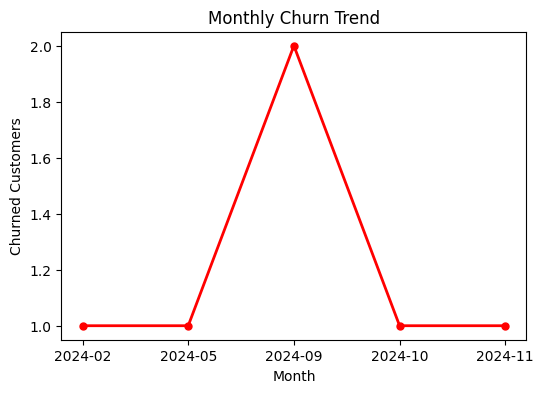

In [147]:
# 1. Monthly Churn Trend (Time Series KPI)
visual_df['cancellation_month'] = visual_df['cancellation_date'].dt.to_period('M')

churn_trend = visual_df[visual_df['churn'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(6,4))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='red', marker='o', ls='-',linewidth=2, markersize=5)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

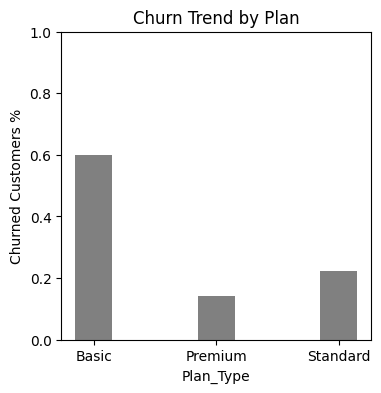

In [161]:
# 2. Churned users by plan type
churn_by_plan = visual_df.groupby('plan_type')['churn'].mean()

plt.figure(figsize=(4,4))
plt.bar(churn_by_plan.index, churn_by_plan.values, color= 'grey', width=0.3)

plt.title('Churn Trend by Plan')
plt.xlabel('Plan_Type')
plt.ylabel('Churned Customers %')
plt.ylim(0,1)
plt.show()

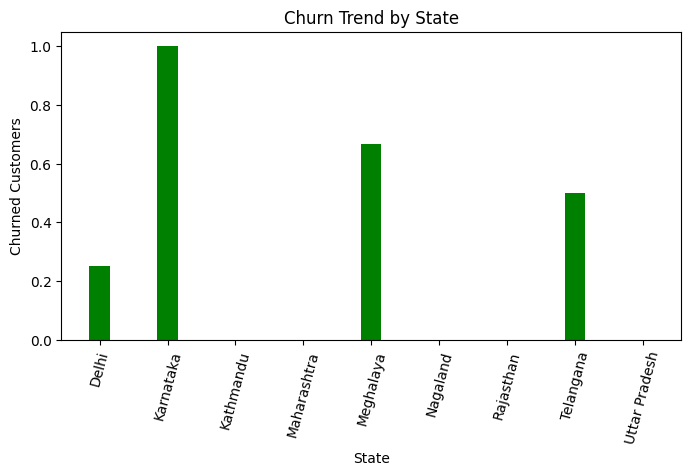

In [169]:
# 3. Churned users by state
churn_by_state = visual_df.groupby('state')['churn'].mean()

plt.figure(figsize=(8,4))
plt.bar(churn_by_state.index, churn_by_state.values, color='g', width=0.3)
plt.xticks( rotation=75)
plt.title('Churn Trend by State')
plt.xlabel('State')
plt.ylabel('Churned Customers')
plt.show()

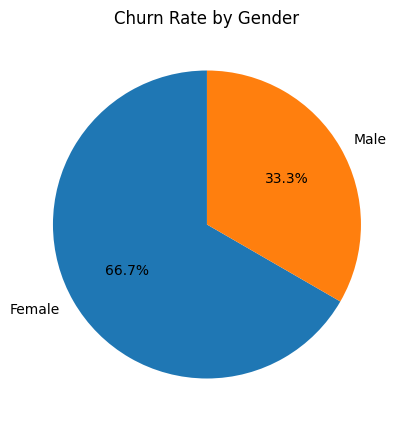

In [189]:
# 4. Users based on gender
churned_gender = visual_df[visual_df['churn'] == 1]['gender'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    churned_gender.values,
    labels=churned_gender.index,
    autopct='%.1f%%',
    startangle=90
)
plt.title('Churn Rate by Gender')
plt.show()

### KEY FINDINGS
* **Churn varies over time:** Monthly churn is not evenly distributed across the observation period, with fluctuations in the number of customers cancelling their subscriptions.

* **Subscription Plan type matters:** Churn rates, churned customer counts, and associated revenue loss vary across subscription types, highlighting differences in churn behavior between customer segments.

* **Subscription duration is strongly associated with churn:** Monthly subscribers have a churn rate of **55.6%**, compared with **8.3%** for annual subscribers, indicating a substantial difference in retention between the two groups.

* **Customer support is strongly associated with churn:** Approximately **19.05%** of customers had an escalation, and escalation showed a **77% correlation with churn** in the dataset. This makes escalated support interactions an important factor to monitor when analyzing customer attrition.

* **Churn has a measurable revenue impact:** The calculated **ARPU is 18.85**, while churned customers represent **73.94 in monthly revenue at risk**, based on their monthly charges.

* **The customer base includes long-term users:** Average customer tenure is approximately **1,548 days**, indicating that the dataset contains a substantial number of long-term customers.

* **Customers can be segmented by churn risk:** The existing churn score was categorized into **low, medium, and high-risk groups**, providing a simpler framework for identifying customers according to their existing churn scores.


### BUSINESS INTERPRETATION

The analysis indicates that customer churn has both customer-retention and financial implications. The variation in churn across subscription types suggests that different customer segments may require different retention strategies rather than applying the same approach to all customers. The Basic plan accounts for the largest share of churn by customer count, while its lower pricing limits the corresponding revenue impact.

Customer support interactions are particularly relevant in the analysis. Around **19.05% of customers experienced an escalation**, and escalation showed a **77% correlation with churn**. This strong relationship suggests that customers involved in escalated support cases could be an important segment to monitor for potential churn. However, the correlation does not establish that escalations directly cause customers to churn.

The financial impact of churn can also be observed through the **73.94 in monthly revenue at risk** associated with churned customers, while the calculated ARPU is **18.85**. This demonstrates why identifying and understanding churned customer segments is important from a revenue perspective.

Finally, the churn-risk categories provide a practical way to segment customers based on their existing churn scores. Combining these risk groups with subscription information and customer-support data could help identify customer segments that deserve further investigation and allow the business to focus retention efforts on areas showing stronger relationships with churn.


### RECOMMENDED BUSINESS ACTIONS

1. **Investigate September 2024 churn**, particularly in Karnataka, for potential pricing, service, technical, or customer-support issues.

2. **Examine monthly subscribers more closely**, given their substantially higher churn rate.

3. **Review the Basic plan** to understand why it has the highest number of churned customers.

4. **Prioritize high- and medium-risk customers**, considering their complaint history when deciding which customers require retention efforts.

5. **Investigate competitors and customer feedback** to understand whether external factors may be contributing to churn.

### CONCLUSION

The analysis highlights customer churn as an important retention and revenue consideration. 
The largest differences in churn are observed across plan and subscription duration, while 
customer escalations also show a strong relationship with churn. These findings provide 
several areas for further investigation, particularly monthly subscribers, the Basic plan, 
and the increase in churn observed during September 2024.